In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [12]:
# Load dataset

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

In [13]:
# preprocess data
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare_log'] = np.log(df['Fare']+1)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['isAlone'] = (df['FamilySize'] == 1).astype(int)
df['Sex'] = df['Sex'].map({'male': 0,'female': 1})
df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
df['Title'] = df['Title'].map(lambda x: x if x in ['Mr', 'Miss', 'Mrs', 'Master'] else 'Rare')
df['Title'] = df['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})


#Verify title column
print(df['Title'].value_counts())

Title
0    517
1    182
2    125
3     40
4     27
Name: count, dtype: int64


In [14]:
# features and split

features= ['Pclass', 'Sex', 'Age', 'Fare_log', 'FamilySize', 'isAlone', 'Title']

X = np.array(df[features].values)
y = np.array(df['Survived'].values)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")

# Check for nulls
print("\nNull counts:")
print(df[features].isnull().sum())


X_train: (712, 7), X_test: (179, 7)

Null counts:
Pclass        0
Sex           0
Age           0
Fare_log      0
FamilySize    0
isAlone       0
Title         0
dtype: int64


In [ ]:
# compare three models


# Train Decision Tree
decisionTreeModel = DecisionTreeClassifier(max_depth=4, random_state=42)
decisionTreeModel.fit(X_train, y_train)

decision_tree_train_accuracy = accuracy_score(y_train, decisionTreeModel.predict(X_train))
decision_tree_test_accuracy = accuracy_score(y_test, decisionTreeModel.predict(X_test))

print(f"Decision Tree Accuracy: train accuracy - {decision_tree_train_accuracy:.3f}, test accuracy - {decision_tree_test_accuracy:.3f}")

    
# Train Random Forest
randomForestModel = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
randomForestModel.fit(X_train, y_train)

random_forest_train_accuracy = accuracy_score(y_train, randomForestModel.predict(X_train))
random_forest_test_accuracy = accuracy_score(y_test, randomForestModel.predict(X_test))

print(f"Random Forest Accuracy: train accuracy - {random_forest_train_accuracy:.3f}, test accuracy - {random_forest_test_accuracy:.3f}")


# Train XGBoost
xgboostModel = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42,eval_metric='logloss',verbosity=0)
xgboostModel.fit(X_train, y_train)

xgboost_train_accuracy = accuracy_score(y_train, xgboostModel.predict(X_train))
xgboost_test_accuracy = accuracy_score(y_test, xgboostModel.predict(X_test))

print(f"XGBoost Accuracy: train accuracy - {xgboost_train_accuracy:.3f}, test accuracy - {xgboost_test_accuracy:.3f}")



results = {
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Train Accuracy': [decision_tree_train_accuracy, random_forest_train_accuracy, xgboost_train_accuracy],
    'Test Accuracy': [decision_tree_test_accuracy, random_forest_test_accuracy, xgboost_test_accuracy]
}

summary = pd.DataFrame(results)
pd.set_option('display.float_format', '{:.3f}'.format)
print(summary.to_string(index=False))

Decision Tree Accuracy: train accuracy - 0.850, test accuracy - 0.838
Random Forest Accuracy: train accuracy - 0.881, test accuracy - 0.844
XGBoost Accuracy: train accuracy - 0.928, test accuracy - 0.821
        Model  Train Accuracy  Test Accuracy
Decision Tree           0.850          0.838
Random Forest           0.881          0.844
      XGBoost           0.928          0.821


In [16]:
# tune xgboost with GridSearchCV

param_grid = {
    'n_estimators': [100, 200,300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.7, 0.8],
}

grid_search = GridSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='logloss',verbosity=0), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"Test accuracy of best model: {accuracy_score(y_test, y_pred):.3f}")
print(f"Test recall of best model: {recall_score(y_test, y_pred):.3f}")
print(f"Test precision of best model: {precision_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:\n", classification_report(y_test, y_pred,target_names=['Died', 'Survived']))

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Best cross-validation accuracy: 0.836
Test accuracy of best model: 0.810
Test recall of best model: 0.725
Test precision of best model: 0.769

Classification Report:
               precision    recall  f1-score   support

        Died       0.83      0.86      0.85       110
    Survived       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



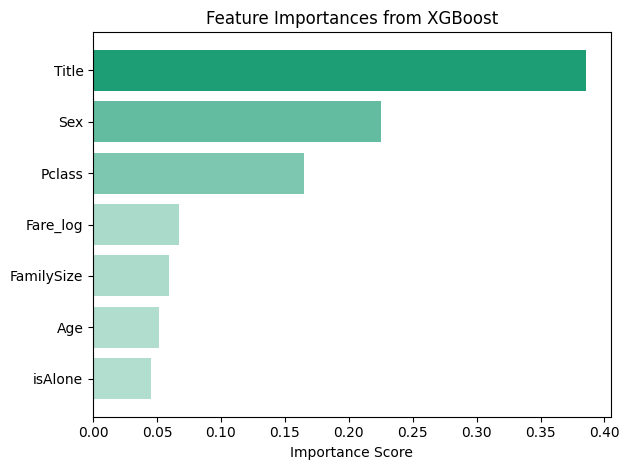

In [17]:
# feature importance chart

import matplotlib.colors as mcolors

feature_importances = best_model.feature_importances_
weights = pd.Series(feature_importances, index=features).sort_values(ascending=True)
max_val = weights.max()
alphas  = [0.25 + 0.75 * (v / max_val) for v in weights]
base_color = '#1D9E75'

r, g, b = mcolors.to_rgb(base_color)
colors = [(r, g, b, a) for a in alphas]
plt.barh(weights.index, weights.values, color=colors)
plt.title('Feature Importances from XGBoost')
Path('outputs').mkdir(exist_ok=True)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/titanic_xgb_feature_importance.png')
plt.show()

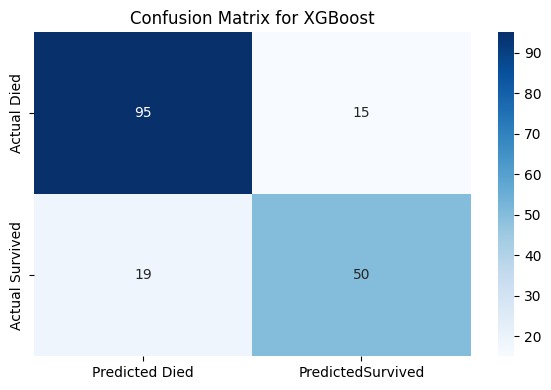

Jack's predicted probability of survival: 2.60%
Rose's predicted probability of survival: 99.08%


In [18]:
# confusion matrix and save model

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Died', 'PredictedSurvived'], yticklabels=['Actual Died', 'Actual Survived'])
plt.title('Confusion Matrix for XGBoost')
plt.tight_layout()
plt.savefig('outputs/titanic_xgb_confusion_matrix.png')
plt.show()

# save model
joblib.dump(best_model, 'outputs/titanic_xgboost_model.pkl')


# Run prediction on sample data

Jack =  [3, 0, 20, np.log(8), 1, 1, 0]
Rose = [1, 1, 17, np.log(72), 3, 0, 1]

Jack_pred_proba = best_model.predict_proba([Jack])
Rose_pred_proba = best_model.predict_proba([Rose])


print(f"Jack's predicted probability of survival: {Jack_pred_proba[0][1]:.2%}")
print(f"Rose's predicted probability of survival: {Rose_pred_proba[0][1]:.2%}")

In [19]:
# Compare all models

lr_model = joblib.load('outputs/titanic_logistic_regression_model.pkl')
lr_scaler = joblib.load('outputs/titanic_logistic_regression_scaler.pkl')

logisticFeatures = ['Pclass', 'Sex', 'Age', 'Fare_log', 'FamilySize', 'isAlone']

lr_X = np.array(df[logisticFeatures].values)
lr_y = np.array(df['Survived'].values)

lr_X_train, lr_X_test, lr_y_train, lr_y_test = train_test_split(lr_X, lr_y, test_size=0.2, random_state=42, stratify=lr_y)
lr_X_test_scaled = lr_scaler.transform(lr_X_test)
lr_X_train_scaled = lr_scaler.fit_transform(lr_X_train)

lr_y_pred = lr_model.predict(lr_X_test_scaled)

d_t_y_pred = decisionTreeModel.predict(X_test)
r_f_y_pred = randomForestModel.predict(X_test)
x_g_y_pred = xgboostModel.predict(X_test)


results = {
    'Models':['LogisticRegression','Decision Tree', 'Random Forest', 'XGBoost', 'XGBoost tuned'],
    'Accuracy':[
        accuracy_score(lr_y_test,lr_y_pred),
        decision_tree_test_accuracy,
        random_forest_test_accuracy,
        xgboost_test_accuracy,
        accuracy_score(y_test,y_pred),
    ],
    'Precision':[
        precision_score(lr_y_test,lr_y_pred),
        precision_score(y_test,d_t_y_pred),
        precision_score(y_test,r_f_y_pred),
        precision_score(y_test,x_g_y_pred),
        precision_score(y_test,y_pred),
    ],
    'Recall':[
        recall_score(lr_y_test,lr_y_pred),
        recall_score(y_test,d_t_y_pred),
        recall_score(y_test,r_f_y_pred),
        recall_score(y_test,x_g_y_pred),
        recall_score(y_test,y_pred),
    ],
    'F1':[
        f1_score(lr_y_test,lr_y_pred),
        f1_score(y_test,d_t_y_pred),
        f1_score(y_test,r_f_y_pred),
        f1_score(y_test,x_g_y_pred),
        f1_score(y_test,y_pred),
    ],
}

summary = pd.DataFrame(results)
print(summary.to_string(index=False))




            Models  Accuracy  Precision  Recall    F1
LogisticRegression     0.810      0.778   0.710 0.742
     Decision Tree     0.838      0.803   0.768 0.785
     Random Forest     0.844      0.825   0.754 0.788
           XGBoost     0.821      0.785   0.739 0.761
     XGBoost tuned     0.810      0.769   0.725 0.746


In [20]:
# Cross validation score comparison

from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': (lr_model, lr_X_train_scaled, lr_y_train),  
    'Decision Tree':       (decisionTreeModel,  X_train, y_train),
    'Random Forest':       (randomForestModel,  X_train, y_train),
    'XGBoost':             (xgboostModel, X_train, y_train),
    'XGBoost tuned':       (best_model, X_train, y_train),
}

for name, (model, X, y) in models.items():
    cv = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name:25} CV: {cv.mean():.3f} ± {cv.std():.3f}")

Logistic Regression       CV: 0.791 ± 0.022
Decision Tree             CV: 0.809 ± 0.033
Random Forest             CV: 0.826 ± 0.022
XGBoost                   CV: 0.816 ± 0.027
XGBoost tuned             CV: 0.836 ± 0.023
